In [1]:
import pandas as pd

df = pd.read_csv('datos/datos_entregas.csv')

df.head()

,ID_pedido,años_experiencia_colaborador,clasificacion_colaborador,latitud_tienda,longitud_tienda,latitud_entrega,longitud_entrega,fecha_pedido,hora_pedido,hora_retirada,clima,trafico,vehiculo,area,categoria_producto,tiempo_entrega
0,ialx566343618,8,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Soleado,Alto,Motocicleta,Urbano,Ropa,120
1,akqg208421122,10,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Lluvioso,Congestion,Scooter,Metropolitano,Electrónicos,165
2,njpu434582536,16,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Tormenta,Bajo,Motocicleta,Urbano,Deportes,130
3,rjto796129700,8,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Soleado,Medio,Motocicleta,Metropolitano,Cosméticos,105
4,zguw716275638,11,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Nublado,Alto,Scooter,Metropolitano,Juguetes,150


In [2]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

llm = ChatGroq(
    api_key=GROQ_API_KEY, 
    model="openai/gpt-oss-120b",
    temperature=0
)

In [4]:
ai_msg = llm.invoke("""Tengo un dataframe llamado 'df' con las columnas 'años_experiencia_colaborador' y 'tiempo_entrega'.
Escribe el código Python con la biblioteca pandas para calcular la correlación entre las dos columnas.
Devuelve la respuesta en Markdown para el trecho de código Python únicamente.
""")

print(ai_msg.content)

```python
# Calcular la correlación entre 'años_experiencia_colaborador' y 'tiempo_entrega'
correlacion = df['años_experiencia_colaborador'].corr(df['tiempo_entrega'])

print("Coeficiente de correlación:", correlacion)
```


In [7]:
correlacion = df['años_experiencia_colaborador'].corr(df['tiempo_entrega'])

print("La correlación entre 'años_experiencia_colaborador' y 'tiempo_entrega' es:", correlacion)

La correlación entre 'años_experiencia_colaborador' y 'tiempo_entrega' es: -0.2516410755060903


In [5]:
from langchain_experimental.tools import PythonAstREPLTool

herramienta_py = PythonAstREPLTool(locals={"df":df})

herramienta_py.invoke("df['años_experiencia_colaborador'].corr(df['tiempo_entrega'])")

C:\Users\leand\AppData\Local\Temp\ipykernel_25256\743168711.py:1: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.tools import PythonAstREPLTool


np.float64(-0.2516410755060903)

In [6]:
llm_con_herramientas = llm.bind_tools([herramienta_py], tool_choice=herramienta_py.name)
respuesta = llm_con_herramientas.invoke("""
Debes llamar a la herramienta `python_repl_ast`.

La herramienta recibe EXACTAMENTE un argumento llamado `query`.

La llamada debe tener esta estructura:

{
    "query": "<código Python>"
}

No uses un argumento llamado `code`.

Usa la herramienta para calcular la correlación entre
df['años_experiencia_colaborador']
y
df['tiempo_entrega'].
""")

respuesta.tool_calls

[{'name': 'python_repl_ast',
  'args': {'query': "df['años_experiencia_colaborador'].corr(df['tiempo_entrega'])"},
  'id': 'fc_96d5b9e7-26bf-45ad-a12c-eace0b5a9a88',
  'type': 'tool_call'}]

In [7]:
from langchain_core.output_parsers.openai_tools import JsonOutputKeyToolsParser

parser = JsonOutputKeyToolsParser(key_name=herramienta_py.name, first_tool_only=True)

cadena = llm_con_herramientas | parser



In [22]:
respuesta = cadena.invoke(
    """
    Debes llamar a la herramienta `python_repl_ast`.

    La herramienta recibe EXACTAMENTE un argumento llamado `query`.

    La llamada debe tener esta estructura:

    {
        "query": "<código Python>"
    }

    No uses un argumento llamado `code`.

    Tengo disponible un DataFrame llamado `df`.

    Genera código Python para calcular la correlación entre:
    df['años_experiencia_colaborador']
    y
    df['tiempo_entrega'].

    IMPORTANTE:
    - Utiliza la biblioteca pandas.
    - Incluye explícitamente todos los imports necesarios dentro del código generado.
    - El código debe ser autocontenido y ejecutable.
    - No asumas que existen alias como `pd` previamente definidos.
    - Separa cada linea de comando con ";".
    """
)
respuesta["query"]

"import pandas as pd; corr = df['años_experiencia_colaborador'].corr(df['tiempo_entrega']); print(corr)"

In [8]:
from langchain_core.prompts import ChatPromptTemplate

system = f"""
Tienes acceso a un dataframe pandas llamado `df`.

Aquí está la salida del comando `df.columns.to_list()`:

'''md
{df.columns.to_list()}
'''

Dada una pregunta del usuario, genera el código Python necesario para responderla.

REGLAS OBLIGATORIAS:

- Debes llamar SIEMPRE a la herramienta `python_repl_ast`.
- La herramienta recibe EXACTAMENTE un argumento llamado `query`.
- No utilices un argumento llamado `code`.
- El argumento `query` debe contener TODO el código Python a ejecutar.
- Incluye explícitamente `import pandas as pd`.
- Cada comando Python generado debe estar separado por `;`.
- Solo puedes utilizar bibliotecas incorporadas de Python y pandas.
- No respondas con Markdown.
- No respondas con texto normal.
- No devuelvas el código fuera de la herramienta.
- Genera únicamente la llamada a `python_repl_ast`.

La llamada debe usar esta estructura:

{{{{
    "query": "<código Python>"
}}}}
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system),
    ("human", "{question}")
])

cadena = prompt | llm_con_herramientas | parser | herramienta_py

In [41]:
respuesta = cadena.invoke({"question":"cuál es el promedio de tiempo de entrega para cada tipo de clima?"})
print(respuesta)

clima
Lluvioso    123.211825
Nublado     138.286773
Soleado     103.664453
Tormenta    123.238509
Name: tiempo_entrega, dtype: float64



In [39]:
respuesta = cadena.invoke({"question":"cuál es la correlación entre los años de experiencia del colaborador y el tiempo de entrega?"})
print(respuesta)

-0.2516410755060903



In [9]:
from langchain_core.prompts import MessagesPlaceholder
from langchain_core.messages import ToolMessage

system = f"""
Tienes acceso a un dataframe pandas llamado `df`.

Aquí está la salida del comando `df.columns.to_list()`:

'''md
{df.columns.to_list()}
'''

Dada una pregunta del usuario, genera el código Python necesario para responderla.
Finalmente, responde en español la pregunta cuando tengas la informacion suficiente para hacerlo.
REGLAS OBLIGATORIAS:

- Debes llamar SIEMPRE a la herramienta `python_repl_ast`.
- La herramienta recibe EXACTAMENTE un argumento llamado `query`.
- No utilices un argumento llamado `code`.
- El argumento `query` debe contener TODO el código Python a ejecutar.
- Incluye explícitamente `import pandas as pd`.
- Cada comando Python generado debe estar separado por `;`.
- Solo puedes utilizar bibliotecas incorporadas de Python y pandas.
- No respondas con Markdown.
- No respondas con texto normal.
- No devuelvas el código fuera de la herramienta.
- Genera únicamente la llamada a `python_repl_ast`.

La llamada debe usar esta estructura:

{{{{
    "query": "<código Python>"
}}}}
"""

def _get_chat_history(x: dict) -> list:
    """
    Analiza la salida de la cadena hasta este punto en una lista de mensajes
    del historial del chat para insertar en el prompt.
    """
    ai_msg = x['ai_msg']
    tool_call_id = x['ai_msg'].additional_kwargs['tool_calls'][0]['id']
    tool_msg = ToolMessage(tool_call_id = tool_call_id, content=str(x['tool_output']))
    return [ai_msg, tool_msg]

In [10]:
system_response = """
Eres un analista de datos.

Responde en español la pregunta del usuario utilizando el resultado
obtenido mediante Python que aparece en el historial de conversación.

No escribas código Python.
No generes llamadas a herramientas.
Responde de manera clara y concisa.
"""

prompt_response = ChatPromptTemplate.from_messages([
    ("system", system_response),
    ("human", "{question}"),
    MessagesPlaceholder(variable_name="chat_history")
])

In [11]:
from langchain_core.runnables import RunnablePassthrough
from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser

cadena = (
    RunnablePassthrough.assign(ai_msg = prompt | llm_con_herramientas)\
    .assign(tool_output = itemgetter("ai_msg") | parser | herramienta_py)\
    .assign(chat_history = _get_chat_history)\
    .assign(response = prompt_response | llm | StrOutputParser())\
    .pick(["tool_output", "response"])
)

In [12]:
respuesta = cadena.invoke({"question":"cuál es el tiempo de entrega promedio para cada tipo de clima?"})

In [13]:
print(respuesta["response"])

El tiempo de entrega promedio según el tipo de clima es:

- **Lluvioso:** 123.21 unidades de tiempo  
- **Nublado:** 138.29 unidades de tiempo  
- **Soleado:** 103.66 unidades de tiempo  
- **Tormenta:** 123.24 unidades de tiempo  

Estos valores representan la media del tiempo de entrega para cada condición climática.


In [58]:
respuesta_2 = cadena.invoke({"question":"Cuál es el promedio de tiempo de entrega?"})
print(respuesta_2['response'])

El promedio de tiempo de entrega es aproximadamente **124.91**.


In [59]:
respuesta_3 = cadena.invoke({"question":"""Cuál es la correlación entre los años de experiencia
                                del colaborador y el tiempo de entrega? Es mayor que la
                                correlación entre la clasificación del colaborador y el
                                tiempo de entrega?
                                """})
print(respuesta_3['response'])

Correlation experience vs delivery time: -0.2516410755060903
Correlation classification vs delivery time: -0.291975378761101
La correlación entre los años de experiencia del colaborador y el tiempo de entrega es mayor que la correlación entre la clasificación del colaborador y el tiempo de entrega. En otras palabras, la experiencia del colaborador está más estrechamente relacionada con el tiempo que tarda en entregar que su clasificación.


In [61]:
respuesta_4 = cadena.invoke({"question":"""Cual es la mediana de las columnas anteriormente mencionadas?
"""})
print(respuesta_4['response'])

La mediana no pudo calcularse porque las columnas que se intentó analizar contienen datos de tipo cadena (string) y, por lo tanto, no son numéricas. Para obtener la mediana es necesario que las columnas sean de tipo numérico (por ejemplo, int o float). Si conviertes o seleccionas solo las columnas con valores numéricos, entonces podrás calcular la mediana sin problemas.


In [14]:
from langchain_experimental.agents import create_pandas_dataframe_agent

# Compatibilidad con Groq:
# PythonAstREPLTool espera obligatoriamente el parámetro "query".
# El modelo tendía a generar {"code": "..."} y Groq rechazaba la tool call.
# Este prefix refuerza el schema esperado: {"query": "<código Python>"}.

prefix_agente = """
Eres un agente especializado en análisis de datos con pandas.

Tienes acceso a un DataFrame llamado `df`.

REGLA CRÍTICA PARA EL USO DE HERRAMIENTAS:

Cuando necesites ejecutar Python debes utilizar la herramienta
`python_repl_ast`.

La herramienta `python_repl_ast` recibe EXACTAMENTE un único
argumento llamado `query`.

La llamada debe tener SIEMPRE esta estructura:

{"query": "<código Python>"}

Nunca utilices un argumento llamado `code`.
Nunca cambies el nombre `query`.
Todo el código Python debe estar dentro de `query`.

Utiliza la herramienta para realizar los cálculos necesarios
y después responde la pregunta del usuario usando los resultados obtenidos.
"""


agente_ejecutor = create_pandas_dataframe_agent(
    llm= llm,
    df = df,
    agent_type = 'tool-calling',
    verbose = True,
    allow_dangerous_code = True,
    prefix=prefix_agente
)

agente_ejecutor.invoke({"input":"""
                                Cuál es la correlación entre los años de experiencia
                                del colaborador y el tiempo de entrega? Es mayor que la
                                correlación entre la clasificación del colaborador y el
                                tiempo de entrega?
                                """
                        }
)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\n# Assuming df is already defined in the environment\ncorr_exp = df['años_experiencia_colaborador'].corr(df['tiempo_entrega'])\ncorr_clas = df['clasificacion_colaborador'].corr(df['tiempo_entrega'])\n(corr_exp, corr_clas)"}`


(np.float64(-0.2516410755060903), np.float64(-0.291975378761101))**Correlaciones calculadas**

| Variable comparada con *tiempo_entrega* | Coeficiente de correlación (Pearson) |
|------------------------------------------|--------------------------------------|
| **años_experiencia_colaborador**         | **‑0.252** |
| **clasificacion_colaborador**            | **‑0.292** |

**Interpretación**

- Ambos coeficientes son negativos, lo que indica que, en promedio, a mayor experiencia o mayor clasificación del colaborador, el tiempo de entrega tiende a ser ligeramente menor.
- El valor **‑0.252** (experiencia) es **mayor** que **‑0.292** (clasificación) porque, 

{'input': '\n                                Cuál es la correlación entre los años de experiencia\n                                del colaborador y el tiempo de entrega? Es mayor que la\n                                correlación entre la clasificación del colaborador y el\n                                tiempo de entrega?\n                                ',
 'output': '**Correlaciones calculadas**\n\n| Variable comparada con *tiempo_entrega* | Coeficiente de correlación (Pearson) |\n|------------------------------------------|--------------------------------------|\n| **años_experiencia_colaborador**         | **‑0.252** |\n| **clasificacion_colaborador**            | **‑0.292** |\n\n**Interpretación**\n\n- Ambos coeficientes son negativos, lo que indica que, en promedio, a mayor experiencia o mayor clasificación del colaborador, el tiempo de entrega tiende a ser ligeramente menor.\n- El valor **‑0.252** (experiencia) es **mayor** que **‑0.292** (clasificación) porque, en la escala

In [15]:
prompt_herramienta_explorador = """
Eres un analista de datos encargado de presentar un resumen informativo sobre un **DataFrame**
a partir de una {pregunta} hecha por el usuario.

A continuación, encontrarás la información general de la base de datos:

================= INFORMACIÓN DEL DATAFRAME =================

Dimensiones: {shape}

Columnas y tipos de datos:
{columns}

Valores nulos por columna:
{nulos}

Cadenas 'nan' (en cualquier capitalización) por columna:
{nans_str}

Filas duplicadas: {duplicados}

============================================================

Con base en esta información, redacta un resumen claro y organizado que contenga:

1. Un título: ## Reporte de información general sobre el dataset,
2. La dimensión total del DataFrame;
3. La descripción de cada columna (incluyendo nombre, tipo de dato y qué representa esa columna);
4. Las columnas que contienen datos nulos, con la respectiva cantidad;
5. Las columnas que contienen cadenas 'nan', con la respectiva cantidad;
6. La existencia (o no) de datos duplicados;
7. Un párrafo sobre los análisis que se pueden realizar con estos datos;
8. Un párrafo sobre los tratamientos que se pueden aplicar a los datos.
"""

prompt_herramienta_estadistica = """ Eres un analista de datos encargado de interpretar resultados estadísticos de una base de datos a partir de una {pregunta} realizada por el usuario.

A continuación, encontrarás las estadísticas descriptivas de la base de datos:

================= ESTADÍSTICAS DESCRIPTIVAS =================

{resumen}

============================================================


Con base en estos datos, elabora un resumen explicativo con un lenguaje claro, accesible y fluido,
destacando los principales puntos de los resultados. Incluye:

1. Un título: ## Informe de estadísticas descriptivas;
2. Una visión general de las estadísticas de las columnas numéricas;
3. Un párrafo sobre cada una de las columnas, comentando información sobre sus valores;
4. Identificación de posibles valores atípicos con base en los valores mínimo y máximo;
5. Recomendaciones de próximos pasos en el análisis en función de los patrones identificados.
"""
prompt_herramienta_visual="""Eres un especialista en visualización de datos. Tu tarea es generar **únicamente el código Python**
para graficar con base en la solicitud del usuario.

## Solicitud del usuario:
"{pregunta}"

## Metadatos del DataFrame:
{columnas}

## Muestra de los datos (3 primeras filas):
{muestra}

## Instrucciones obligatorias:
1. Usa las bibliotecas `matplotlib.pyplot` (como `plt`) y `seaborn` (como `sns`);
2. Define el tema con `sns.set_theme()`;
3. Asegúrate de que todas las columnas mencionadas en la solicitud existan en el DataFrame llamado `df`;
4. Elige el tipo de gráfico adecuado según el análisis solicitado:
- **Distribución de variables numéricas**: `histplot`, `kdeplot`, `boxplot` o `violinplot`
- **Distribución de variables categóricas**: `countplot`
- **Comparación entre categorías**: `barplot`
- **Relación entre variables**: `scatterplot`
- **Series temporales**: `lineplot`, con el eje X formateado como fechas
5. Configura el tamaño del gráfico con `figsize=(8, 4)`;
6. Añade título y etiquetas (`labels`) apropiadas a los ejes;
7. Posiciona el título a la izquierda con `loc='left'`, deja el `pad=20` y usa `fontsize=14`;
8. Mantén los ticks del eje X sin rotación con `plt.xticks(rotation=0)`;
9. Elimina los bordes superior y derecho del gráfico con `sns.despine()`;
10. Finaliza el código con `plt.show()`.

Devuelve ÚNICAMENTE el código Python generado separando cada instrucción con ';',
sin ningún texto adicional ni explicación.

Código Python:
"""

In [ ]:
from langchain_core.tools import tool
from langchain_core.prompts import PromptTemplate
import matplotlib.pyplot as plt
import seaborn as sns


@tool(return_direct=True)
def herramienta_informaciones_df(pregunta: str):
    """
    Utiliza esta herramienta siempre que el usuario solicite informaciones generales sobre el
    DataFrame, incluyendo el número de columnas y filas, nombres de las columnas y sus tipos de
    datos, conteo de datos nulos y duplicados para dar un panorama general sobre el archivo.
    """
    shape = df.shape
    columns = df.dtypes
    nulos = df.isnull().sum()
    duplicados = df.duplicated().sum()
    nans_str = df.apply(lambda col: col[~col.isna()].astype(str).str.strip().str.lower().eq('nan')).sum()
    plantilla_respuesta = PromptTemplate(
        template=prompt_herramienta_explorador,
        input_variables=[
            "pregunta",
            "shape", 
            "columns", 
            "nulos", 
            "nans_str", 
            "duplicados"
        ]
    )

    cadena = plantilla_respuesta | llm | StrOutputParser()
    respuesta = cadena.invoke ({
        "pregunta": pregunta,
        "shape": shape,
        "columns": columns,
        "nulos": nulos,
        "nans_str": nans_str,
        "duplicados": duplicados
    })

    return respuesta

@tool(return_direct=True)
def herramienta_resumen_estadistico(pregunta: str) -> str:
    """
    Utiliza esta herramienta siempre que el usuario solicite un resumen estadístico completo
    y descriptivo de la base de datos, incluyendo varias estadísticas (promedio, desvío típico,
    mínimo, máximo, etc.).
    """
    resumen = df.describe(include='number').transpose().to_string()
    plantilla_respuesta = PromptTemplate(
        template=prompt_herramienta_estadistica,
        input_variables=[
            "pregunta",
            "resumen"
        ]
    )

    cadena = plantilla_respuesta | llm | StrOutputParser()
    respuesta = cadena.invoke({
        "pregunta": pregunta,
        "resumen": resumen
    })

    return respuesta

@tool(return_direct=True)
def herramienta_generar_grafico(pregunta: str) -> str:
    """Utiliza esta herramienta siempre que el usuario solicite un gráfico a partir de un DataFrame
    pandas ('df') con base en una instrucción del usuario. La instrucción podrá contener solicitudes
    como por ejemplo: 'Crea un gráfico de promedio de tiempo de entrega por clima', 'grafica la
    distribución del tiempo de entrega', 'Haz un plot de la relación entre la clasificación de los
    agentes y el tiempo de entrega', entre otros. Las Palabras-clave comunes que indican el uso de
    esta herramienta incluyen: 'crea un gráfico', 'haz un plot', 'visualiza', 'muestra la distribución', 'representación visual', etc.
    """
    columnas_info = "\n".join([f'{col} ({dtype})' for col, dtype in df.dtypes.items()])
    muestra_datos = df.head(3).to_dict(orient='records')
    plantilla_respuesta = PromptTemplate(
        template=prompt_herramienta_visual,
        input_variables=[
            "pregunta",
            "columnas",
            "muestra"
        ]
    )
    cadena = plantilla_respuesta | llm | StrOutputParser()

    script_bruto = cadena.invoke({
    "pregunta": pregunta,
    "columnas": columnas_info,
    "muestra": muestra_datos
    })

    script_limpio = script_bruto.replace('```python', '').replace('```', '')

    exec_globals = {
    "df": df,
    "plt": plt,
    "sns": sns
    }

    exec_locals = {}

    exec(script_limpio, exec_globals, exec_locals)

    fig = plt.gcf()
    return fig

from langchain_core.tools import Tool

herramienta_codigos_python = PythonAstREPLTool(
    name="codigos_python",
    locals={"df": df},
    description="""
    Utiliza esta herramienta cuando el usuario solicite cálculos,
    consultas o transformaciones específicas sobre el DataFrame `df`.

    Ejemplos:
    - calcular el promedio de una columna;
    - calcular correlaciones;
    - obtener valores únicos;
    - filtrar datos;
    - realizar agrupaciones.

    No utilizar para información general del DataFrame,
    resúmenes estadísticos completos o generación de gráficos.
    """
)

tools = [
    herramienta_informaciones_df,
    herramienta_resumen_estadistico,
    herramienta_generar_grafico,
    herramienta_codigos_python,
]

for herramienta in tools:
    print(
        herramienta.name,
        "->",
        type(herramienta).__name__,
        "| return_direct:",
        herramienta.return_direct
    )
    

informaciones_df -> StructuredTool | return_direct: True
resumen_estadistico -> StructuredTool | return_direct: True
generar_grafico -> StructuredTool | return_direct: True
codigos_python -> PythonAstREPLTool | return_direct: False


In [80]:
reporte_informaciones = informaciones_df.invoke("¿Cuáles son las informaciones generales sobre el dataframe?")
print(reporte_informaciones)

## Reporte de información general sobre el dataset  

---

### 1. Dimensión del DataFrame  
- **Filas:** 43 739  
- **Columnas:** 16  

---

### 2. Descripción de cada columna  

| Nombre de columna                     | Tipo de dato | Qué representa (descripción sugerida) |
|---------------------------------------|--------------|----------------------------------------|
| **ID_pedido**                         | `str`        | Identificador único de cada pedido. |
| **años_experiencia_colaborador**      | `int64`      | Años de experiencia del colaborador (repartidor) asignado al pedido. |
| **clasificacion_colaborador**         | `float64`    | Puntuación o rating del colaborador (ej. basada en evaluaciones de clientes). |
| **latitud_tienda**                    | `float64`    | Coordenada de latitud de la tienda o punto de origen del pedido. |
| **longitud_tienda**                   | `float64`    | Coordenada de longitud de la tienda o punto de origen del pedido. |
| **latitud_entre

In [81]:
from IPython.display import display, Markdown

display(Markdown(reporte_informaciones))

## Reporte de información general sobre el dataset  

---

### 1. Dimensión del DataFrame  
- **Filas:** 43 739  
- **Columnas:** 16  

---

### 2. Descripción de cada columna  

| Nombre de columna                     | Tipo de dato | Qué representa (descripción sugerida) |
|---------------------------------------|--------------|----------------------------------------|
| **ID_pedido**                         | `str`        | Identificador único de cada pedido. |
| **años_experiencia_colaborador**      | `int64`      | Años de experiencia del colaborador (repartidor) asignado al pedido. |
| **clasificacion_colaborador**         | `float64`    | Puntuación o rating del colaborador (ej. basada en evaluaciones de clientes). |
| **latitud_tienda**                    | `float64`    | Coordenada de latitud de la tienda o punto de origen del pedido. |
| **longitud_tienda**                   | `float64`    | Coordenada de longitud de la tienda o punto de origen del pedido. |
| **latitud_entrega**                   | `float64`    | Coordenada de latitud del domicilio o punto de entrega. |
| **longitud_entrega**                  | `float64`    | Coordenada de longitud del domicilio o punto de entrega. |
| **fecha_pedido**                      | `str`        | Fecha en la que se realizó el pedido (formato día‑mes‑año). |
| **hora_pedido**                       | `str`        | Hora exacta en la que se generó el pedido. |
| **hora_retirada**                     | `str`        | Hora en la que el colaborador retiró el pedido en la tienda. |
| **clima**                             | `str`        | Condiciones climáticas al momento del pedido (ej. soleado, lluvioso, etc.). |
| **trafico**                           | `str`        | Nivel de tráfico en la ruta de entrega (ej. bajo, medio, alto). |
| **vehiculo**                          | `str`        | Tipo de vehículo utilizado para la entrega (ej. moto, coche, bicicleta). |
| **area**                              | `str`        | Área o zona geográfica donde se ubica la entrega (puede ser un barrio o distrito). |
| **categoria_producto**               | `str`        | Categoría del producto entregado (ej. alimentos, electrónica, ropa, etc.). |
| **tiempo_entrega**                    | `int64`      | Tiempo total de entrega en minutos (desde la retirada hasta la entrega). |

---

### 3. Columnas con datos nulos  

| Columna                | Cantidad de valores nulos |
|------------------------|---------------------------|
| clasificacion_colaborador | 54 |
| clima                  | 14 754 |
| trafico                | 91 |
| vehiculo               | 3 558 |
| area                   | 1 290 |
| categoria_producto    | 27 222 |

*Todas las demás columnas no presentan valores nulos.*

---

### 4. Columnas con cadenas `'nan'` (cualquier capitalización)  

| Columna                | Cantidad de ocurrencias de la cadena `'nan'` |
|------------------------|----------------------------------------------|
| hora_pedido            | 91 |
| **Resto de columnas** | 0 |

> Nota: La cuenta de `'nan'` se refiere a la presencia literal del texto `"nan"` (o `"NaN"`, `"NAN"`, etc.) dentro de los valores de la columna, no a los valores nulos de pandas.

---

### 5. Duplicados  

- **Filas duplicadas:** 0  
  No existen filas idénticas en todo el DataFrame.

---

### 6. Posibles análisis con estos datos  

1. **Análisis de desempeño logístico**  
   - Relacionar el tiempo de entrega con variables como clima, tráfico, tipo de vehículo y experiencia del colaborador para identificar factores que aumentan o reducen la rapidez de la entrega.  

2. **Segmentación de pedidos**  
   - Agrupar pedidos por categoría de producto, área o tipo de vehículo y comparar métricas de tiempo de entrega y satisfacción (clasificación del colaborador).  

3. **Modelado predictivo**  
   - Construir modelos de regresión o clasificación que predigan el tiempo de entrega o la probabilidad de que un pedido supere un umbral de tiempo, usando variables geográficas, temporales y contextuales (clima, tráfico).  

4. **Análisis de recursos humanos**  
   - Evaluar cómo la experiencia y la clasificación del colaborador influyen en la eficiencia de la entrega y en la satisfacción del cliente.  

5. **Estudios de patrones temporales**  
   - Analizar la distribución de pedidos por hora del día, día de la semana o mes, y su relación con la congestión de tráfico y condiciones climáticas.  

---

### 7. Tratamientos recomendados para los datos  

1. **Manejo de valores nulos**  
   - **`clasificacion_colaborador`**: Imputar con la media o mediana, o bien usar el rating del colaborador más cercano en tiempo.  
   - **`clima`, `trafico`, `vehiculo`, `area`, `categoria_producto`**: Considerar imputación basada en la moda, o crear una categoría “Desconocido” para preservar la información sin introducir sesgo.  

2. **Conversión de tipos**  
   - Transformar `fecha_pedido`, `hora_pedido` y `hora_retirada` a tipos datetime para facilitar cálculos de diferencias horarias y extracción de atributos (día de la semana, hora del día, etc.).  

3. **Limpieza de cadenas `'nan'`**  
   - Reemplazar las ocurrencias de la cadena `'nan'` en `hora_pedido` (y en cualquier otra columna) por valores nulos reales (`np.nan`) antes de aplicar imputaciones.  

4. **Ingeniería de características**  
   - Calcular la distancia geodésica entre tienda y punto de entrega a partir de latitud/longitud (p. ej., usando la fórmula de Haversine).  
   - Derivar variables como “duración entre pedido y retirada” y “día de la semana”.  

5. **Detección y tratamiento de outliers**  
   - Revisar valores extremos en `tiempo_entrega` y en la distancia calculada; aplicar winsorization o eliminación según el contexto del negocio.  

6. **Codificación de variables categóricas**  
   - Aplicar codificación one‑hot o target encoding para `clima`, `trafico`, `vehiculo`, `area` y `categoria_producto` antes de entrenar modelos de machine learning.  

7. **Normalización/Estandarización**  
   - Escalar variables numéricas (años de experiencia, clasificación, distancia, tiempo de entrega) si se van a usar algoritmos sensibles a la escala.  

Con estos pasos de limpieza, transformación e ingeniería de características, el dataset quedará listo para análisis exploratorio, visualizaciones y modelado predictivo que aporten valor a la operación logística.

In [87]:
informe_estadistico = resumen_estadistico.invoke("Cuáles son las estadísticas descriptivas de los datos?")
display(Markdown(informe_estadistico))

## Informe de estadísticas descriptivas  

A continuación se presenta un resumen comprensible de las principales características de la base de datos, basada en las estadísticas descriptivas obtenidas para cada variable numérica.

---

### 1. Visión general de las columnas numéricas  

| Variable                     | N (observaciones) | Media | Desvío estándar | Mínimo | Q1 (25 %) | Mediana (50 %) | Q3 (75 %) | Máximo |
|------------------------------|-------------------|-------|-----------------|--------|-----------|----------------|-----------|--------|
| **años_experiencia_colaborador** | 43 739 | 12.11 | 3.11 | 1 | 9 | 12 | 15 | 20 |
| **clasificacion_colaborador**    | 43 685 | 4.63 | 0.33 | 1 | 4.5 | 4.7 | 4.9 | 5 |
| **latitud_tienda**                | 43 739 | 17.21 | 7.76 | –30.90 | 12.93 | 18.55 | 22.73 | 30.91 |
| **longitud_tienda**               | 43 739 | 70.66 | 21.48 | –88.37 | 73.17 | 75.90 | 78.05 | 88.43 |
| **latitud_entrega**               | 43 739 | 17.46 | 7.34 | 0.01 | 12.99 | 18.63 | 22.79 | 31.05 |
| **longitud_entrega**              | 43 739 | 70.82 | 21.15 | 0.01 | 73.28 | 76.00 | 78.10 | 88.56 |
| **tiempo_entrega (minutos)**      | 43 739 | 124.91 | 51.92 | 10 | 90 | 125 | 160 | 270 |

---

### 2. Comentario por columna  

#### **años_experiencia_colaborador**  
- La media (≈ 12 años) indica que, en promedio, los colaboradores tienen más de una década de experiencia.  
- La mayoría (50 %) se sitúa entre 9 y 15 años (Q1‑Q3).  
- El rango total (1‑20 años) sugiere que hay algunos colaboradores muy nuevos (1 año) y otros con experiencia muy alta (20 años).  

#### **clasificacion_colaborador**  
- La escala parece ir de 1 a 5, con una media de 4.63 y poca dispersión (σ≈0.33).  
- El 75 % superior está por encima de 4.9, lo que indica una evaluación muy positiva en general.  
- El valor mínimo de 1 es atípico respecto a la concentración en los valores 4‑5 y merece revisión (posible error de captura o caso excepcional).  

#### **latitud_tienda** y **latitud_entrega**  
- Ambas variables presentan medias cercanas (≈ 17.2°) y rangos similares (≈ ‑31 ° a 31 °).  
- Los cuartiles indican que la mayor parte de los puntos se concentran entre 13° y 23°, lo que corresponde a la zona geográfica principal de operación.  
- Los valores mínimos negativos (‑30.9°) y los máximos cercanos a 31° están muy alejados del cuartil superior, lo que sugiere posibles tiendas o entregas fuera del área habitual (por ejemplo, en regiones extremas o errores de geocodificación).  

#### **longitud_tienda** y **longitud_entrega**  
- Las medias rondan los 70‑71°, con una dispersión considerable (σ≈21°).  
- Los cuartiles (≈ 73‑78°) indican que la mayor parte de los locales y entregas se encuentran en una franja estrecha de longitud.  
- Los valores mínimos negativos (‑88°) y los máximos superiores a 88° están muy fuera del rango intercuartílico, lo que nuevamente apunta a posibles outliers geográficos o errores de registro.  

#### **tiempo_entrega**  
- El tiempo medio de entrega es de 125 minutos, con una mediana idéntica, lo que muestra una distribución bastante simétrica alrededor de ese valor.  
- El rango (10‑270 min) es amplio; los valores menores a 30 min y mayores a 200 min pueden considerarse atípicos respecto a los cuartiles (90‑160 min).  
- La alta desviación estándar (≈ 52 min) indica variabilidad significativa entre entregas, lo que podría deberse a distancia, tráfico, o condiciones operativas.  

---

### 3. Posibles valores atípicos (outliers)  

| Variable | Señal de posible outlier | Comentario |
|----------|--------------------------|------------|
| **años_experiencia_colaborador** | 1 año (mínimo) | Muy bajo comparado con Q1=9; revisar si corresponde a un nuevo colaborador o a un error de captura. |
| **clasificacion_colaborador** | 1 (mínimo) | Incongruente con la alta concentración en 4‑5; probable error de registro. |
| **latitud_tienda** | –30.90° (mínimo) | Muy alejado del Q3=22.73°; podría ser una tienda fuera de la zona de operación o un error de latitud. |
| **longitud_tienda** | –88.37° (mínimo) | Extremadamente fuera del rango intercuartílico; revisar coordenadas. |
| **latitud_entrega** | 0.01° (mínimo) | Posible error de geocodificación (cerca del ecuador) o entrega fuera de la zona habitual. |
| **longitud_entrega** | 0.01° (mínimo) | Similar al caso anterior; verificar datos. |
| **tiempo_entrega** | 10 min (mínimo) y 270 min (máximo) | 10 min parece demasiado rápido; 270 min (4.5 h) es mucho más largo que el Q3=160 min; ambos valores merecen inspección. |

---

### 4. Recomendaciones para los próximos pasos  

1. **Validación de datos geográficos**  
   - Realizar una verificación de coordenadas (latitud/longitud) contra un mapa de la zona de operación.  
   - Corregir o eliminar los registros con valores fuera del rango esperado (p.ej., latitudes negativas o longitudes < 0).  

2. **Revisión de valores extremos en variables categóricas**  
   - Inspeccionar los casos con **clasificacion_colaborador = 1** y **años_experiencia_colaborador = 1** para confirmar su veracidad.  
   - Si se trata de errores, corregir o excluir esos registros antes de análisis posteriores.  

3. **Análisis de la distribución del tiempo de entrega**  
   - Aplicar técnicas de detección de outliers (IQR, Z‑score) al **tiempo_entrega** para identificar entregas anómalas.  
   - Investigar las causas de entregas extremadamente rápidas o lentas (distancia, tipo de producto, condiciones climáticas, etc.).  

4. **Segmentación geográfica**  
   - Crear variables de zona (por ejemplo, “norte”, “sur”, “este”, “oeste”) a partir de latitud y longitud para comparar métricas (tiempo de entrega, clasificación) entre regiones.  

5. **Modelado predictivo**  
   - Con los datos limpios, considerar modelos de regresión o árboles de decisión para predecir **tiempo_entrega** a partir de la ubicación, experiencia del colaborador y clasificación.  
   - Evaluar la influencia de la **experiencia del colaborador** y la **clasificación** en la eficiencia de la entrega.  

6. **Reportes continuos**  
   - Establecer un proceso de monitoreo periódico de estas métricas para detectar desviaciones tempranas y mantener la calidad de los datos.  

---

**Conclusión**  
El análisis descriptivo muestra que la mayor parte de los colaboradores son experimentados y bien calificados, y que la operación se concentra en una zona geográfica estrecha. Sin embargo, existen varios valores atípicos, especialmente en coordenadas y en la variable de tiempo de entrega, que deben ser revisados y corregidos antes de avanzar a análisis más profundos o a la construcción de modelos predictivos. Implementar las recomendaciones propuestas permitirá obtener insights más fiables y mejorar la toma de decisiones operativas.

<string>:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.



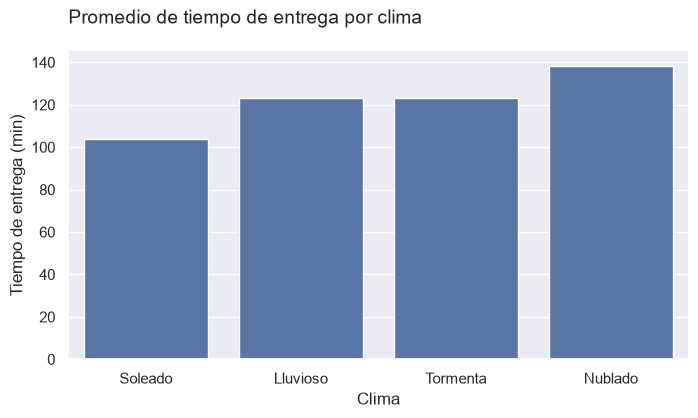

Figure(640x480)


<Figure size 640x480 with 0 Axes>

In [89]:
grafico_generado = generar_grafico.invoke("Crea un gráfico del promedio de tiempo de entrega por clima")
print(grafico_generado)

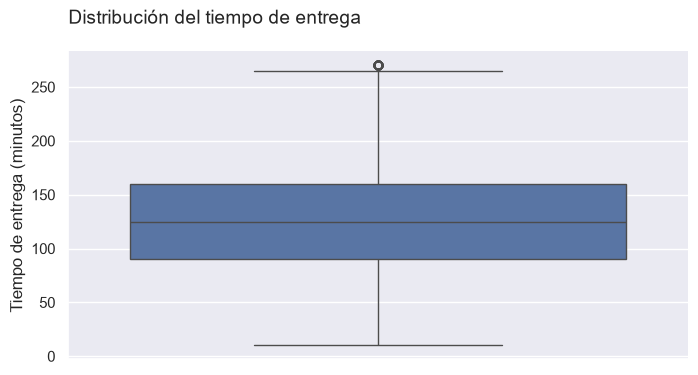

Figure(640x480)


<Figure size 640x480 with 0 Axes>

In [90]:
grafico_generado_2 = generar_grafico.invoke("Haz un boxplot del tiempo de entrega")
print(grafico_generado_2)

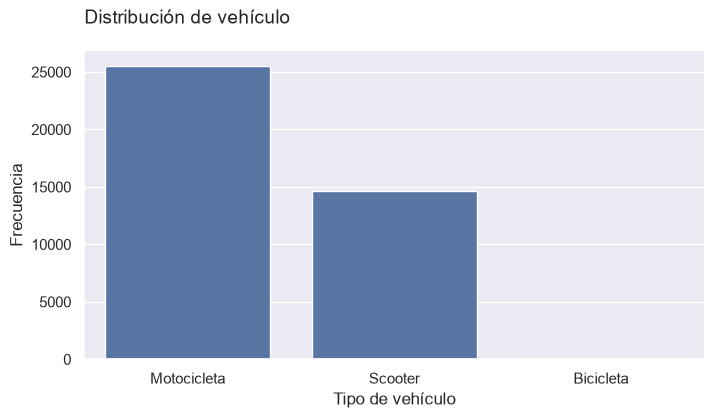

Figure(640x480)


<Figure size 640x480 with 0 Axes>

In [91]:
grafico_generado_3 = generar_grafico.invoke("Gráfico de distribución de vehiculo")
print(grafico_generado_3)

<string>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



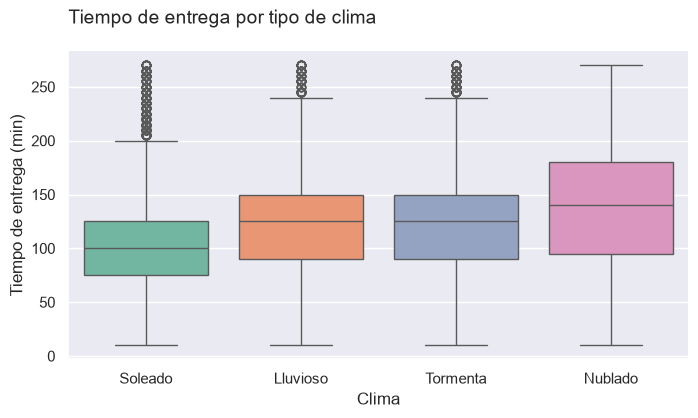

Figure(640x480)


<Figure size 640x480 with 0 Axes>

In [92]:
grafico_generado_4 = generar_grafico.invoke("realiza un boxplot del tiempo de entrega para cada tipo de clima, utilizando una paleta de colores categórica.")
print(grafico_generado_4)

informaciones_df -> StructuredTool | return_direct: True
resumen_estadistico -> StructuredTool | return_direct: True
generar_grafico -> StructuredTool | return_direct: True
codigos_python -> PythonAstREPLTool | return_direct: False


In [34]:
### Codigo antiguo del curso

# from langchain_classic import hub

# prompt_react = hub.pull("hwchase17/react")

### -----------------------------------------------------------

# En versiones actuales de LangSmith, los prompts públicos están bloqueados
# por defecto por seguridad. Como confiamos en el prompt público
# "hwchase17/react" usado por el curso, habilitamos explícitamente su descarga.

from langsmith import Client

client = Client()

prompt_react = client.pull_prompt(
    "hwchase17/react",
    dangerously_pull_public_prompt=True
)

print(prompt_react.template)

Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}


In [36]:
df_head = df.head(3).to_markdown()

prompt_react_es = PromptTemplate(
    input_variables = ['input','agent_scratchpad','tools','tool_names'],
    partial_variables = {"df_head":df_head},
    template = """
                Eres un asistente que responde en castellano.

                Tienes acceso a un dataframe pandas llamado `df`.
                Aquí están las primeras filas del DataFrame, obtenidas usando `df.head().to_markdown()`:

                {df_head}

                Responde a las siguientes preguntas de la mejor manera posible.
                Para este fin, tienes acceso a las siguientes herramientas:

                {tools}

                Usa el siguiente formato:

                Question: La pregunta de entrada que debes responder
                Thought: Debes siempre pensar en lo que debes hacer
                Action: La acción que será ejecutada, debe ser una de las [{tool_names}]
                Action Input: La entrada para la acción
                Observation: El resultado de la acción
                ... (este Thought/Action/Action Input/Observation puede repetirse N veces)
                Thought: Ahora sé la respuesta final
                Final Answer: la respuesta final para la pregunta de entrada inicial.

                Comienza!

                Question: {input}
                Thought: {agent_scratchpad}
                """
)

In [39]:
from langchain_classic.agents import create_react_agent, AgentExecutor
tools = [   
    herramienta_informaciones_df,
    herramienta_resumen_estadistico,
    herramienta_generar_grafico,
    herramienta_codigos_python,]

NameError: name 'herramienta_informaciones_df' is not defined